<a href="https://colab.research.google.com/github/WooyeongJang/ml-with-pytorch/blob/main/2%EC%A3%BC%EC%B0%A8%20%EC%8B%9C%EA%B0%81%ED%99%94%20%ED%8F%AC%ED%95%A8%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets

In [ ]:
# 데이터셋
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [ ]:
print (type(iris))
print (type(X))
print (type(y))
print (y.shape)

<class 'sklearn.utils._bunch.Bunch'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(150,)


In [ ]:
print(iris.target_names)
print(y[10], "#",iris.target_names[y[10]])

['setosa' 'versicolor' 'virginica']
0 # setosa


In [ ]:
# 훈련  데이터셋, 테스트 데이터셋
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)
print("y_test의 레이블 빈도수", np.bincount(y_test))

y_test의 레이블 빈도수 [15 15 15]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
print("y_test의 레이블 빈도수", np.bincount(y_test))

y_test의 레이블 빈도수 [14 18 13]


In [ ]:
# 다양한 방법

import numpy as np
from collections import Counter
from sklearn.datasets import load_iris

# 예제 데이터 (iris label)
iris = load_iris()
y = iris.target

print("배열 shape:", y.shape)
print("데이터:", y[:10], "...")

print("\n1️⃣ np.unique() 사용 (가장 일반적인 방법)")
values, counts = np.unique(y, return_counts=True)
print("values:", values)
print("counts:", counts)
print("dict 형태:", dict(zip(values, counts)))

print("\n2️⃣ np.bincount() 사용 (정수 라벨일 때 빠름)")
print(np.bincount(y))

print("\n3️⃣ Counter 사용 (Python 표준 라이브러리)")
print(Counter(y))

print("\n4️⃣ 반복문으로 직접 계산")
freq = {}
for v in y:
    freq[v] = freq.get(v, 0) + 1
print(freq)

배열 shape: (150,)
데이터: [0 0 0 0 0 0 0 0 0 0] ...

1️⃣ np.unique() 사용 (가장 일반적인 방법)
values: [0 1 2]
counts: [50 50 50]
dict 형태: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}

2️⃣ np.bincount() 사용 (정수 라벨일 때 빠름)
[50 50 50]

3️⃣ Counter 사용 (Python 표준 라이브러리)
Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})

4️⃣ 반복문으로 직접 계산
{np.int64(0): 50, np.int64(1): 50, np.int64(2): 50}


In [ ]:
# 전처리
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)


In [ ]:
# 퍼셉트론 훈련
from sklearn.linear_model import Perceptron

ppn = Perceptron(
  eta0=0.1,
  random_state=1
)
ppn.fit(X_train_std, y_train)


Perceptron(eta0=0.1, random_state=1)

In [ ]:
# 테스트
y_pred = ppn.predict(X_test_std)
print("테스트 샘플:",len(y_pred))
print("오분류 샘플: %d" % (y_test != y_pred).sum())

테스트 샘플: 45
오분류 샘플: 12


In [ ]:
# 성능평가
from sklearn.metrics import accuracy_score
print('정확도: %.2f' % accuracy_score(y_test, y_pred))

print('정확도: %.2f' % ppn.score(X_test_std, y_test))

정확도: 0.73
정확도: 0.73


In [ ]:
# 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    multi_class='ovr'
)
lr.fit(X_train_std, y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10.0, multi_class='ovr')

In [ ]:
# 테스트
y_pred = lr.predict(X_test_std)
print("테스트 샘플:",len(y_pred))
print("오분류 샘플: %d" % (y_test != y_pred).sum())

테스트 샘플: 45
오분류 샘플: 3


In [ ]:
# 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    multi_class='multinomial'
)
lr.fit(X_train_std, y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10.0, multi_class='multinomial')

In [ ]:
# 테스트
y_pred = lr.predict(X_test_std)
print("테스트 샘플:",len(y_pred))
print("오분류 샘플: %d" % (y_test != y_pred).sum())

테스트 샘플: 45
오분류 샘플: 2


In [ ]:
# SVM
from sklearn.svm import SVC
svm = SVC(
    kernel='linear',
    C = 1.0,
    random_state=1
    )
svm.fit(X_train, y_train)


SVC(kernel='linear', random_state=1)

In [ ]:
# 테스트
y_pred = svm.predict(X_test_std)
print("테스트 샘플:",len(y_pred))
print("오분류 샘플: %d" % (y_test != y_pred).sum())

테스트 샘플: 45
오분류 샘플: 31


In [ ]:
from sklearn.linear_model import SGDClassifier

ppn = SGDClassifier(loss='perceptron')
lr = SGDClassifier(loss='log')
svm = SGDClassifier(loss='hinge')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0,
                       X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)


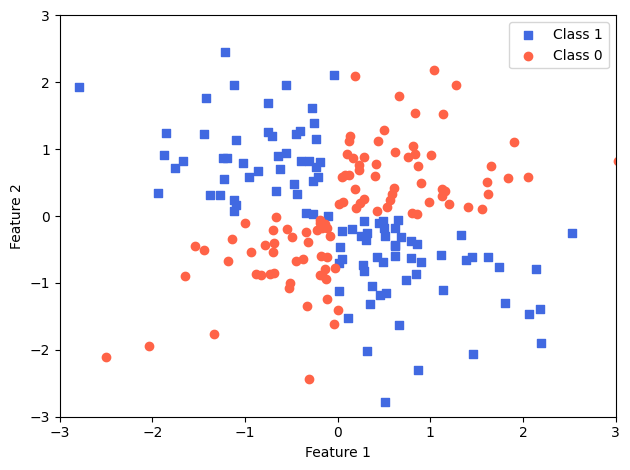

In [ ]:
plt.scatter(X_xor[y_xor == 1, 0],
            X_xor[y_xor == 1, 1],
            c='royalblue',
            marker='s',
            label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0],
            X_xor[y_xor == 0, 1],
            c='tomato',
            marker='o',
            label='Class 0')

plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend(loc='best')
plt.tight_layout()
plt.show()

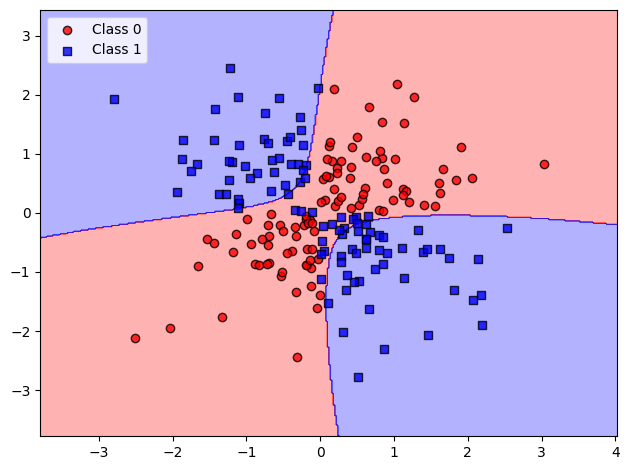

In [ ]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.10, C=10.0)
svm.fit(X_xor, y_xor)

plot_decision_regions(X_xor, y_xor,
                      classifier=svm)

plt.legend(loc='upper left')
plt.tight_layout()
#plt.savefig('figures/03_14.png', dpi=300)
plt.show()

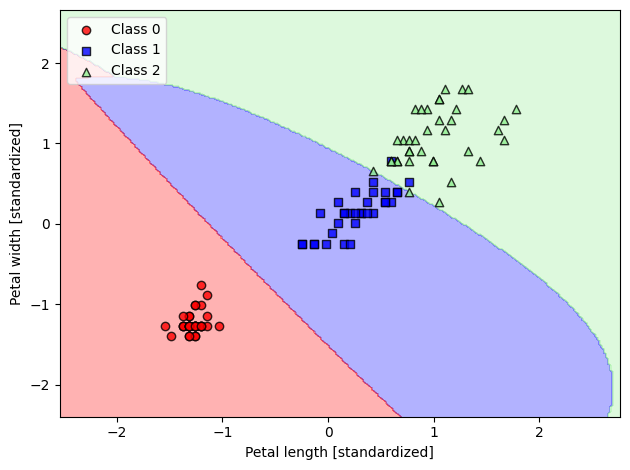

In [ ]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.2, C=1.0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_train_std, y_train,
                      classifier=svm)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

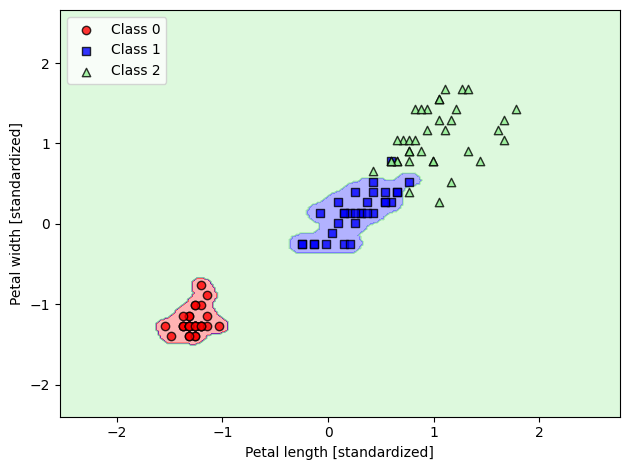

In [ ]:
svm = SVC(kernel='rbf', random_state=1, gamma=100, C=1.0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_train_std, y_train,
                      classifier=svm)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# 맷플롯립 호환성을 체크합니다
import matplotlib
from distutils.version import LooseVersion


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # 마커와 컬러맵을 설정합니다.
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # 결정 경계를 그립니다.
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # 클래스 샘플을 그립니다
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

    # 테스트 샘플을 부각하여 그립니다.
    if test_idx:
        # 모든 샘플을 그립니다.
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='Test set')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5,
                           p=2,
                           metric='minkowski')
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion='gini',
                                    max_depth=4,
                                    random_state=1)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=1)